# 06 Validierung & Sensitivitätsanalyse

**PA1 ZHAW IUNR** | Bächler, Haag, Reichlin | Betreuer: Patrick Laube

1. **Standort-Trefferquote (Hit Rate)** – Reale Standorte vs. geeignete Fläche
2. **Mann-Whitney U Test** – Standort-Werte vs. zufällige Constraint-Pixel
3. **Kruskal-Wallis** – Verteilung nach Status-Gruppen
4. **OAT-Sensitivitätsanalyse** – 10 Kriterien ±20%
5. **Validierungskarte** – WLC + Referenz-Polygone + Standort-Punkte
6. **Standort-Zoom** – Constraint-Maske + WLC Detail

**Input:**
```
outputs/suitability_wlc.tif
outputs/top_sites.gpkg
data/raw/validation/alpine_pv_plants.csv
data/raw/validation/validation_epsg_2056.tif
data/processed/constraints/constraint_mask_s2.tif
data/processed/criteria/f01–f10_*.tif
```

**Status-Gewichtung:**
- connected to grid: 1.0
- under construction: 0.8
- in planning: 0.6
- deferred: 0.3
- discarded: 0.0

## 1. Setup & Imports

In [62]:
from pathlib import Path                                                    # Cross-platform file path handling
import geopandas as gpd                                                    # Geospatial vector data manipulation
import numpy as np                                                         # Numerical array operations and math
import pandas as pd                                                        # Tabular data handling and analysis
import rasterio                                                            # Read/write raster GIS data (GeoTIFF)
from rasterio.features import shapes as rio_shapes                         # Raster-to-vector polygon extraction
from shapely.geometry import Point, shape as shp_shape, box as shp_box     # Shapely geometry constructors
from pyproj import Transformer                                             # CRS reprojection for point data
from scipy.stats import mannwhitneyu, kruskal, spearmanr                   # Non-parametric statistical tests
import matplotlib.pyplot as plt                                            # Plotting and visualization library
import matplotlib.colors as mcolors                                        # Custom colormaps and color normalization
from matplotlib.patches import Patch                                       # Legend patch elements
import math                                                                # Angle calculations for label placement
import warnings
warnings.filterwarnings("ignore")                                          # Suppress non-critical warnings
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})                   # Plot defaults

# Load data paths
RAW  = Path("../data/raw")                                                 # Raw input data directory
PROC = Path("../data/processed")                                           # Processed data directory
OUT  = Path("../outputs")                                                  # Output directory
OUT_F = OUT / "figures"                                                    # Figures subdirectory
OUT_T = OUT / "tables"                                                     # Tables subdirectory
for d in [OUT_F, OUT_T]:
    d.mkdir(parents=True, exist_ok=True)                                   # Create if not existing

# Define constants
CRS      = "EPSG:2056"                                                     # Target CRS (LV95)
RES      = 25                                                              # Raster resolution [m]
NODATA   = -9999.0                                                         # NoData value
BG_COLOR = "#6161AD"                                                       # Background color for maps

# Status classification (ordinal weights)
STATUS_WEIGHTS = {                                                         # Validation weights per status
    "connected to grid": 1.0,                                              # Operational → full weight
    "under construction": 0.8,                                             # Approved → high weight
    "in planning": 0.6,                                                    # Concrete project → medium
    "deferred": 0.3,                                                       # On hold → low
    "discarded": 0.0,                                                      # Cancelled → negative control
}
STATUS_ORDER = list(STATUS_WEIGHTS.keys())                                 # Ordered list for plots
STATUS_COLORS = {                                                          # Colors per status
    "connected to grid": "#2ecc71",                                        # Green
    "under construction": "#3498db",                                       # Blue
    "in planning": "#e67e22",                                              # Orange
    "deferred": "#f1c40f",                                                 # Yellow
    "discarded": "#e74c3c",                                                # Red
}

# Constraint mask colormap (colorblind-safe: Wong palette)
MASK_COLORS   = ["#D55E00", "#0072B2"]                                     # Excluded=orange, Suitable=blue
cmap_mask     = mcolors.ListedColormap(MASK_COLORS)                        # Binary colormap
norm_mask     = mcolors.BoundaryNorm([0, 0.5, 1], cmap_mask.N)            # 0 → excluded, 1 → suitable
MASK_LEGEND   = [                                                          # Legend patches
    Patch(facecolor="#D55E00", edgecolor="black", label="Excluded"),
    Patch(facecolor="#0072B2", edgecolor="black", label="Suitable"),
]

# Suitability classes (identical to 04_wlc — keep synchronized)
CLASSES = {                                                                # Class boundaries
    1: (0.0, 0.6, "Unsuitable or Low suitability"),
    2: (0.6, 0.7, "Moderate suitability"),
    3: (0.7, 0.8, "Suitable"),
    4: (0.8, 0.9, "Well suited"),
    5: (0.9, 1.0, "Very well suited"),
}
CLASS_COLORS = ["#313695", "#74add1", "#ffffbf", "#f46d43", "#a50026"]     # Colorblind-safe
CLASS_LABELS = [v[2] for v in CLASSES.values()]                            # Label strings
cmap_cls = mcolors.ListedColormap(CLASS_COLORS)                            # Discrete colormap
norm_cls = mcolors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5,5.5], cmap_cls.N)   # Class boundaries

def suit_to_class(arr, mask_2d):
    """Classify continuous suitability [0–1] into 5 discrete classes."""
    c = np.zeros(arr.shape, dtype=np.float32)                              # Init with 0
    m = mask_2d & (arr > 0)                                                # Valid pixels
    v = arr[m]                                                             # Extract values
    cls = np.ones(v.shape)                                                 # Default: class 1
    for cls_id, (lo, hi, _) in CLASSES.items():                            # Assign classes
        if cls_id > 1:
            cls[v >= lo] = cls_id                                          # Overwrite higher class
    c[m] = cls                                                             # Write back
    return np.where(m, c, np.nan)                                          # NaN outside mask

print("✓ Setup OK")


✓ Setup OK


## 2. Data Loading

In [63]:
print("=== Loading suitability map & constraint mask ===\n")

# WLC suitability map
suit_path = OUT / "suitability_wlc.tif"                                    # Primary input
if not suit_path.exists():                                                 # Fallback
    suit_path = OUT / "suitability_postprocessed.tif"
with rasterio.open(suit_path) as src:                                      # Open raster
    suit = src.read(1)                                                     # Read band 1
    suit_tf = src.transform                                                # Affine transformation
    height, width = suit.shape                                             # Raster dimensions

# Constraint mask (binary 0/1)
with rasterio.open(PROC / "constraints/constraint_mask_s2.tif") as src:    # Open mask
    cmask = src.read(1)                                                    # Read band 1

valid = (cmask == 1)                                                       # Suitable pixels
print(f"  WLC map: {suit_path.name} | {width}×{height}")
print(f"  Suitable pixels: {valid.sum():,} ({valid.sum()*RES*RES/1e6:.0f} km²)")

=== Loading suitability map & constraint mask ===

  WLC map: suitability_wlc.tif | 5641×4010
  Suitable pixels: 626,229 (391 km²)


In [64]:
print("\n=== Loading validation data ===\n")

# CSV with 22 alpine PV sites (WGS84 → LV95)
df_plants = pd.read_csv(RAW / "validation/alpine_pv_plants.csv")           # Load CSV
tf_proj = Transformer.from_crs("EPSG:4326", CRS, always_xy=True)          # WGS84 → LV95
df_plants["E"], df_plants["N"] = tf_proj.transform(                        # Transform coordinates
    df_plants["lon"].values, df_plants["lat"].values)
df_plants["weight"] = df_plants["status"].map(STATUS_WEIGHTS)              # Status → ordinal weight
df_plants["geometry"] = [Point(e, n) for e, n in                           # Create point geometries
                         zip(df_plants["E"], df_plants["N"])]
gdf_plants = gpd.GeoDataFrame(df_plants, geometry="geometry", crs=CRS)    # GeoDataFrame

# Extract suitability value per site (5×5 window maximum)
suit_values, in_constraint = [], []                                        # Collect per-site info
for _, r in gdf_plants.iterrows():                                         # Loop through sites
    col = int((r.E - suit_tf.c) / suit_tf.a)                              # Pixel column
    row = int((r.N - suit_tf.f) / suit_tf.e)                              # Pixel row
    if 0 <= row < height and 0 <= col < width:                            # Inside raster bounds
        r_min, r_max = max(0, row-2), min(height, row+3)                  # 5×5 window rows
        c_min, c_max = max(0, col-2), min(width, col+3)                   # 5×5 window cols
        suit_values.append(suit[r_min:r_max, c_min:c_max].max())          # Max in window
        in_constraint.append("✓" if cmask[row, col] == 1 else "✗")       # Check constraint
    else:                                                                  # Outside bounds
        suit_values.append(np.nan)
        in_constraint.append("OOB")

gdf_plants["suit_value"] = suit_values                                     # Add to GeoDataFrame
gdf_plants["in_constraint"] = in_constraint                                # Add constraint status

# Print summary table
print(gdf_plants[["name", "status", "weight", "suit_value",
                   "in_constraint"]].to_string(index=False))

# Export detail CSV
gdf_plants[["name", "status", "weight", "capacity_kw",                    # Select columns
            "suit_value", "in_constraint"]].to_csv(
    OUT_T / "validation_point_detail.csv", index=False)                    # Save CSV
print(f"\n  ✓ {OUT_T / 'validation_point_detail.csv'}")


=== Loading validation data ===

                        name             status  weight   suit_value in_constraint
               Albigna Solar  connected to grid     1.0 -9999.000000             ✗
               Bernina Solar        in planning     0.6 -9999.000000             ✗
                Caischavedra  connected to grid     1.0 -9999.000000             ✗
                 Heinzenberg          discarded     0.0     0.713406             ✗
                 Lago di Lei  connected to grid     1.0 -9999.000000             ✗
                Madrisasolar under construction     0.8     0.836185             ✓
                   NalpSolar under construction     0.8 -9999.000000             ✗
                Nandro Solar          discarded     0.0 -9999.000000             ✗
       Ovra Solara Camplauns          discarded     0.0     0.819308             ✓
         Ovra Solara Magriel        in planning     0.6     0.795918             ✗
           Ovra Solara Rueun          discarded     0

In [ ]:
print("\n=== Loading & matching validation polygons (1-to-1) ===\n")

# Validation raster → polygons
val_path = RAW / "validation/validation_epsg_2056.tif"                     # Validation TIF
with rasterio.open(val_path) as src:                                       # Open raster
    val_rast = src.read(1)                                                 # Read band 1
    val_tf = src.transform                                                 # Affine transformation

val_mask = val_rast > 0                                                    # Binary mask
val_polys = [shp_shape(geom) for geom, v                                   # Extract polygons
             in rio_shapes(val_mask.astype(np.uint8),
                           mask=val_mask, transform=val_tf) if v != 0]

gdf_val = gpd.GeoDataFrame(geometry=val_polys, crs=CRS)                   # Create GeoDataFrame
gdf_val = gdf_val.explode(index_parts=False).reset_index(drop=True)       # Explode multipolygons
gdf_val["poly_id"] = gdf_val.index + 1                                    # Sequential ID
gdf_val["area_ha"] = gdf_val.area / 1e4                                   # Area in hectares
print(f"  Validation polygons: {len(gdf_val)}")
print(f"  Total area: {gdf_val.area_ha.sum():.1f} ha")

# ── 1-to-1 greedy matching ───────────────────────────────────────────────
MAX_MATCH_DIST = 5000                                                      # 5 km tolerance

# Build all candidate pairs (polygon_idx, plant_idx, distance) within threshold
candidates = []
for pi in gdf_val.index:                                                   # Loop polygons
    for qi, plant_row in gdf_plants.iterrows():                            # Loop plants
        d = gdf_val.loc[pi, "geometry"].distance(plant_row.geometry)      # Distance
        if d <= MAX_MATCH_DIST:                                            # Within threshold
            candidates.append((d, pi, qi))                                # Store triple

candidates.sort(key=lambda x: x[0])                                       # Sort by distance

# Init empty columns
for col in ["name", "status", "capacity_kw", "annual_yield_gwh", "suit_value"]:
    gdf_val[col] = None
gdf_val["match_dist_m"] = np.nan

assigned_polys  = set()                                                    # Already matched polygons
assigned_plants = set()                                                    # Already matched plants

for dist, pi, qi in candidates:                                            # Greedy assignment
    if pi in assigned_polys or qi in assigned_plants:                     # Skip if used
        continue
    plant = gdf_plants.loc[qi]                                            # Get plant data
    gdf_val.loc[pi, "name"]             = plant["name"]
    gdf_val.loc[pi, "status"]           = plant["status"]
    gdf_val.loc[pi, "capacity_kw"]      = plant["capacity_kw"]
    gdf_val.loc[pi, "annual_yield_gwh"] = plant["annual_yield_gwh"]
    gdf_val.loc[pi, "suit_value"]       = plant["suit_value"]             # WLC suitability score
    gdf_val.loc[pi, "match_dist_m"]     = dist
    assigned_polys.add(pi)
    assigned_plants.add(qi)

matched = gdf_val["name"].notna().sum()
print(f"  Matched (1-to-1, ≤{MAX_MATCH_DIST/1000:.0f} km): {matched}/{len(gdf_val)} polygons")
unmatched_plants = set(gdf_plants.index) - assigned_plants
if unmatched_plants:
    print(f"  Unmatched plants ({len(unmatched_plants)}): "
          + ", ".join(gdf_plants.loc[list(unmatched_plants), "name"].tolist()))

def fmt_suit(v):
    """Format suit_value: NODATA → readable label, else 3 decimals."""
    if pd.isna(v):
        return "—"
    if float(v) == NODATA:
        return "ausserh. Mask"
    return f"{float(v):.3f}"

# Summary table
print(f"\n  {'Poly':>4s} {'Area':>6s} {'Dist':>7s} {'WLC':>14s} {'Name':<28s} {'Status'}")
print(f"  {'-'*86}")
for _, r in gdf_val.iterrows():
    nm   = r["name"]   if r["name"]   else "—"
    st   = r["status"] if r["status"] else "—"
    dist = f"{r.match_dist_m:.0f}m" if pd.notna(r.match_dist_m) else "—"
    sv   = fmt_suit(r.suit_value)
    print(f"  {r.poly_id:>4.0f} {r.area_ha:>5.1f}ha {dist:>7s} {sv:>14s} {nm:<28s} {st}")



=== Loading & matching validation polygons (1-to-1) ===

  Validation polygons: 34
  Total area: 133.2 ha
  Matched (1-to-1, ≤5 km): 18/34 polygons
  Unmatched plants (4): Albigna Solar, Solarkraftwerk Samedan, Lago di Lei, PVA Punt dal Gall

  Poly   Area    Dist    WLC Name                         Status
  ------------------------------------------------------------------------------
     1   2.0ha    133m  0.836 Madrisasolar                 under construction
     2   4.3ha      0m -9999.000 Solaranlage Vorab            under construction
     3   0.3ha    110m  0.853 Scuol Solar                  in planning
     4   0.4ha       —      — —                            —
     5   0.2ha       —      — —                            —
     6   3.5ha       —      — —                            —
     7   1.2ha       —      — —                            —
     8   0.8ha       —      — —                            —
     9   0.6ha       —      — —                            —
    10   9.0ha

## 3. Standort-Zoom: Constraint-Maske + WLC

=== Constraint & WLC zoom (Madrisasolar) ===

  ✓ ..\outputs\figures\validation_zoom_madrisasolar.png


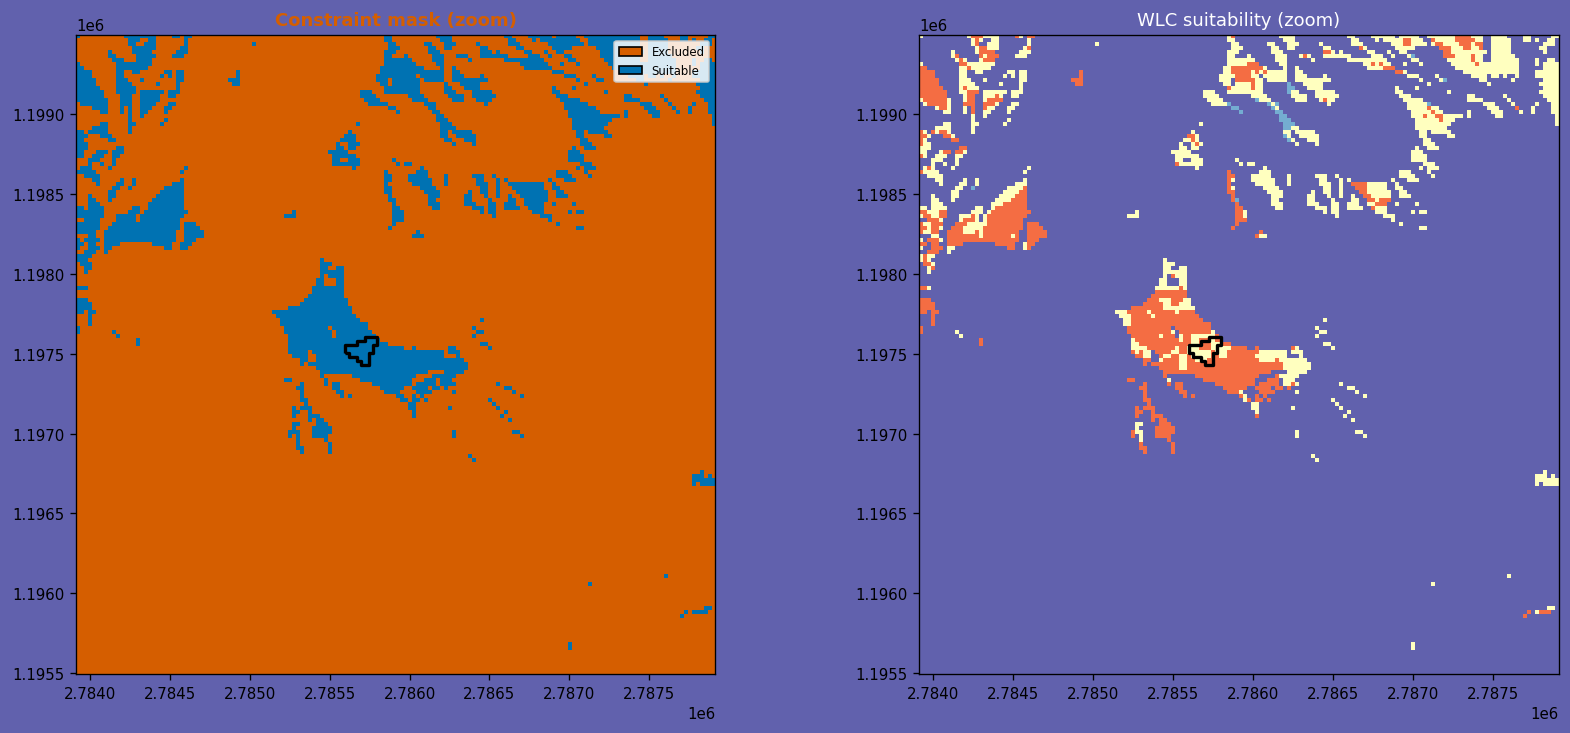

In [66]:
print("=== Constraint & WLC zoom (Madrisasolar) ===\n")

# Select site for zoom
madrisa = gdf_plants[gdf_plants["name"] == "Madrisasolar"].iloc[0]         # Reference site
col_m = int((madrisa.E - suit_tf.c) / suit_tf.a)                          # Pixel column
row_m = int((madrisa.N - suit_tf.f) / suit_tf.e)                          # Pixel row
pad = 80                                                                   # Window: ~2 km at 25 m

# Extract windows
r_min, r_max = max(0, row_m-pad), min(height, row_m+pad)                  # Row bounds
c_min, c_max = max(0, col_m-pad), min(width, col_m+pad)                   # Col bounds
mask_win = cmask[r_min:r_max, c_min:c_max]                                # Constraint window
wlc_win  = suit[r_min:r_max, c_min:c_max]                                 # WLC window

# World extent for imshow
xmin = suit_tf.c + c_min * suit_tf.a                                      # Left bound
xmax = suit_tf.c + c_max * suit_tf.a                                      # Right bound
ymin = suit_tf.f + r_max * suit_tf.e                                      # Bottom bound
ymax = suit_tf.f + r_min * suit_tf.e                                      # Top bound
ext = (xmin, xmax, ymin, ymax)                                            # Extent tuple

# Validation polygons in zoom area
zoom_box = shp_box(xmin, ymin, xmax, ymax)                                # Zoom bounding box
gdf_zoom = gdf_val[gdf_val.intersects(zoom_box)] if not gdf_val.empty else gdf_val

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True,  # Two panels
                         facecolor=BG_COLOR)

# Left: Constraint mask — orange=excluded, blue=suitable
ax = axes[0]
ax.set_facecolor(BG_COLOR)
ax.imshow(mask_win, cmap=cmap_mask, norm=norm_mask, interpolation="none", # Colorblind-safe binary
          origin="upper", extent=ext)
if not gdf_zoom.empty:                                                    # Validation polygons
    gdf_zoom.boundary.plot(ax=ax, edgecolor="black", linewidth=2)
ax.set_title("Constraint mask (zoom)", color="#D55E00", fontweight="bold") # Orange title
ax.legend(handles=MASK_LEGEND, loc="upper right", fontsize=7,             # Color legend
          framealpha=0.85)
ax.set_aspect("equal")

# Right: WLC classified
ax = axes[1]
ax.set_facecolor(BG_COLOR)
wlc_cls = suit_to_class(wlc_win, wlc_win > 0)                            # Classify
ax.imshow(wlc_cls, cmap=cmap_cls, norm=norm_cls, interpolation="none",    # Show classified
          origin="upper", extent=ext)
if not gdf_zoom.empty:                                                    # Validation polygons
    gdf_zoom.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=2)
ax.set_title("WLC suitability (zoom)", color="white")
ax.set_aspect("equal")

for ax in axes:
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")

fig.savefig(OUT_F / "validation_zoom_madrisasolar.png",
            dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
print(f"  ✓ {OUT_F / 'validation_zoom_madrisasolar.png'}")


## 4. Validierungskarte — WLC + Referenz + Standorte

=== Validation map ===

  ✓ ..\outputs\figures\validation_plants_map.png
  Output size: ~14,400 × 12,000 px


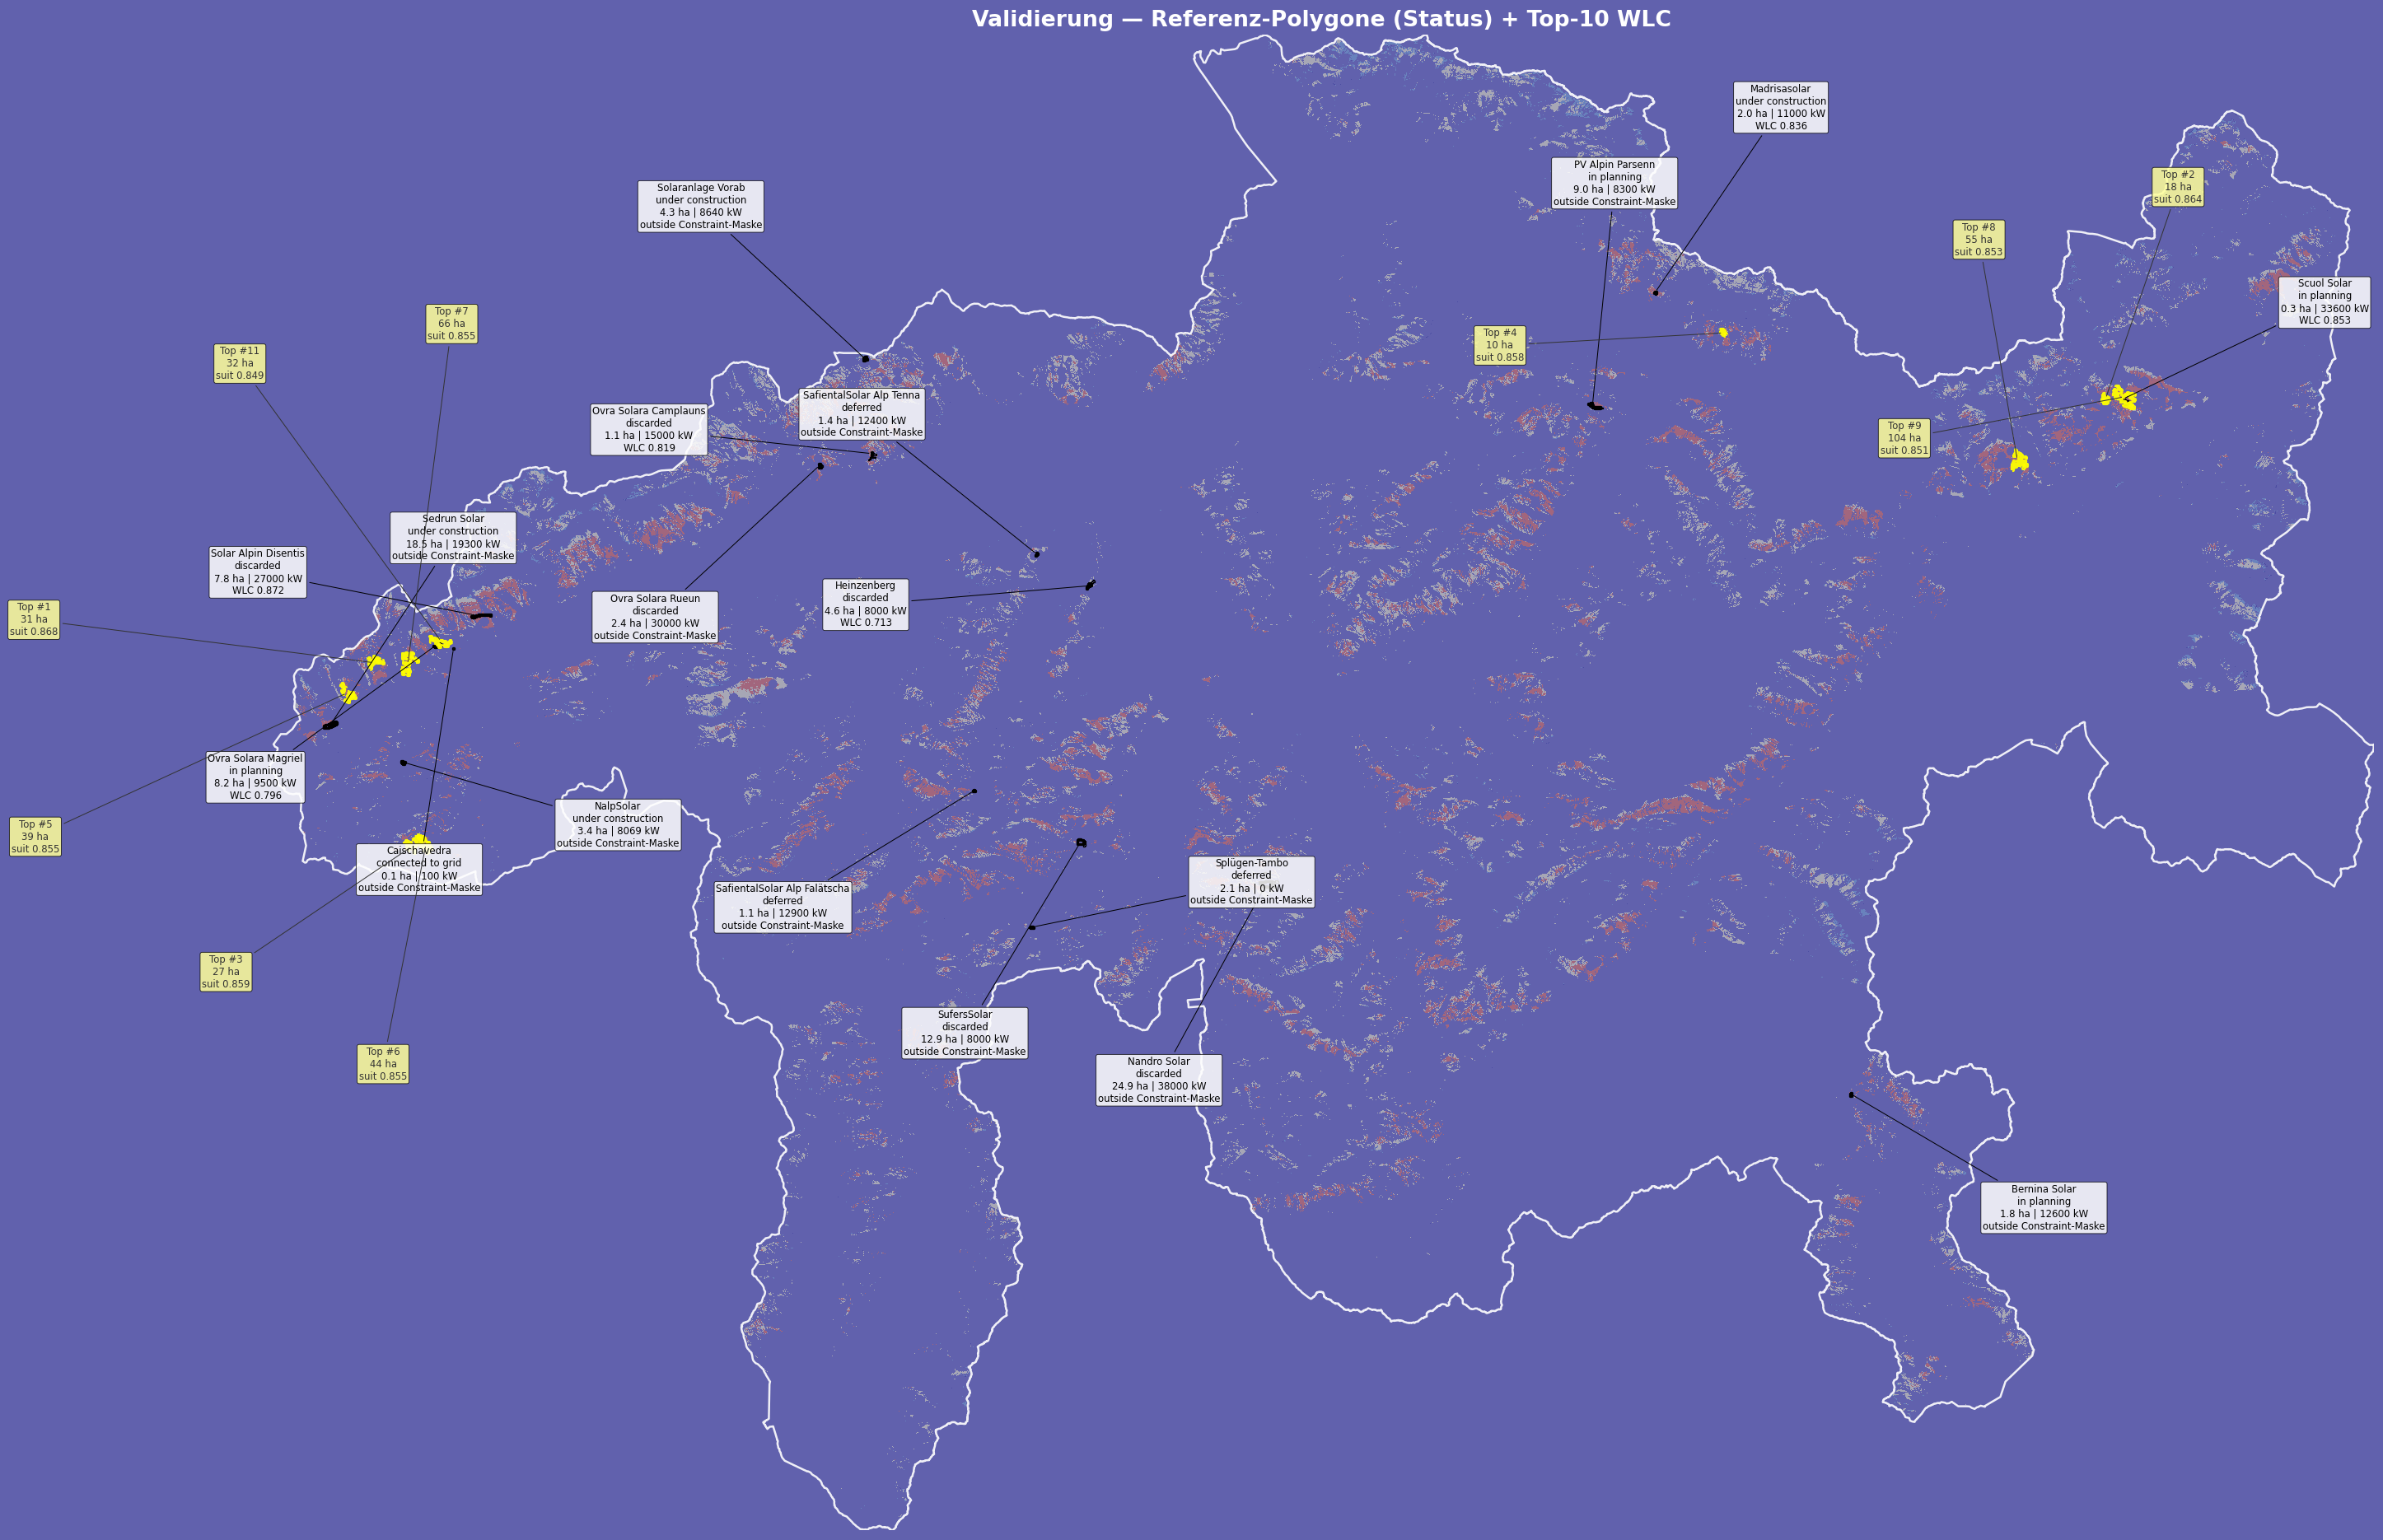

In [83]:
print("=== Validation map ===\n")

# Canton border
gr_border = gpd.read_file(                                                 # Load GR boundary
    RAW / "swissboundaries/graubuenden_kantonsgrenze.shp").to_crs(CRS)
gr_bounds = gr_border.total_bounds                                         # Extent for zoom

# Top sites from post-processing
sites_path = OUT / "top_sites.gpkg"                                        # Top sites file
gdf_sites = gpd.read_file(sites_path) if sites_path.exists() else None    # Load if exists
top10 = gdf_sites.nlargest(10, "mean_suit") if gdf_sites is not None else None

# Classified WLC for background
cls_wlc = suit_to_class(suit, valid)                                       # Classify full raster
extent = (suit_tf.c, suit_tf.c + width * suit_tf.a,                       # Map extent
          suit_tf.f + height * suit_tf.e, suit_tf.f)

fig, ax = plt.subplots(figsize=(24, 20), constrained_layout=True,         # Large map (24×20 @ 600 dpi = 14400×12000 px)
                       facecolor=BG_COLOR)
ax.set_facecolor(BG_COLOR)                                                 # Background

# WLC background (faded)
ax.imshow(cls_wlc, cmap=cmap_cls, norm=norm_cls, alpha=0.45,             # Show classified WLC
          extent=extent, origin="upper", aspect="equal", interpolation="nearest")

# Canton border
gr_border.boundary.plot(ax=ax, color="white", linewidth=1.5, alpha=0.9)   # White border

# Validation polygons colored by status
matched_val = gdf_val[gdf_val["status"].notna()]                           # Polygons with status
unmatched_val = gdf_val[gdf_val["status"].isna()]                         # Polygons without match

# Unmatched polygons: 
if not unmatched_val.empty:                                                # If unmatched exist
    unmatched_val.plot(ax=ax, facecolor="none", edgecolor="black",       # No fill, gray edge
                       linewidth=0.8)

# Matched polygons: 
for status in STATUS_ORDER:                                                # Each status group
    subset = matched_val[matched_val["status"] == status]                 # Filter
    if not subset.empty:                                                  # If non-empty
        subset.plot(ax=ax, facecolor="none",                               # No fill
                    edgecolor="black", linewidth=2.0,
                    label=status)

# Top-10 sites from WLC (yellow outline)
if top10 is not None and not top10.empty:                                  # If top sites exist
    top10.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2.5,         # Yellow highlight
                        linestyle="--", alpha=0.95)

# Label placement helper
placed_labels = []                                                         # Track placed positions

def place_label(ax, geom, text, fontsize=7, color="black", fc="white"):
    """Place label with collision avoidance."""
    pt = geom.representative_point()                                       # Anchor point
    base_angle = math.atan2(pt.y - (gr_bounds[1]+gr_bounds[3])/2,         # Angle from center
                            pt.x - (gr_bounds[0]+gr_bounds[2])/2)
    dist = 15000                                                           # Label distance [m]
    best_x, best_y = pt.x + 5000, pt.y + 5000                            # Fallback
    for attempt in range(2):                                               # Two distance attempts
        for step in range(24):                                            # 24 × 15° = full circle
            angle = base_angle + step * math.pi / 12                      # Candidate angle
            tx = pt.x + math.cos(angle) * dist                           # Candidate X
            ty = pt.y + math.sin(angle) * dist                           # Candidate Y
            if all(math.hypot(tx-px, ty-py) >= 12000                     # Check separation
                   for px, py in placed_labels):
                best_x, best_y = tx, ty                                   # Accept
                break
        else:
            dist += 8000                                                   # Increase radius
            continue
        break
    placed_labels.append((best_x, best_y))                                # Register
    ax.annotate(text, xy=(pt.x, pt.y), xytext=(best_x, best_y),          # Draw annotation
                fontsize=fontsize, ha="center", va="center", color=color,
                bbox=dict(boxstyle="round,pad=0.2", fc=fc, alpha=0.85, lw=0.5),
                arrowprops=dict(arrowstyle="-", color=color, lw=0.6))

# Labels for matched validation polygons
for _, r in matched_val.iterrows():                                        # Each matched polygon
    label = f"{r['name']}\n{r['status']}\n{r['area_ha']:.1f} ha"        # Name + status + area
    if pd.notna(r.get("capacity_kw")):                                    # Add capacity if known
        label += f" | {r['capacity_kw']:.0f} kW"
    sv = r.get("suit_value")
    if pd.notna(sv):
        if float(sv) == NODATA:                                           # Outside constraint mask
            label += "\noutside Constraint-Maske"
        else:
            label += f"\nWLC {float(sv):.3f}"
    place_label(ax, r.geometry, label)

# Labels for top-10 sites (yellow background)
if top10 is not None:                                                      # If top sites exist
    for _, r in top10.iterrows():                                         # Each top site
        label = f"Top #{r['rang']:.0f}\n{r['area_ha']:.0f} ha"          # Rank + area
        if "mean_suit" in r.index:                                        # Add suitability
            label += f"\nsuit {r['mean_suit']:.3f}"
        place_label(ax, r.geometry, label,
                    color="#333333", fc="#FFFF99")                         # Yellow background

ax.set_xlim(gr_bounds[0], gr_bounds[2])                                   # Zoom to GR
ax.set_ylim(gr_bounds[1], gr_bounds[3])                                   # Zoom to GR
ax.set_title("Validierung — Referenz-Polygone (Status) + Top-10 WLC",    # Title
             fontsize=16, color="white", fontweight="bold")
ax.set_aspect("equal")                                                    # Square pixels
ax.set_axis_off()                                                         # Hide axes

fig.savefig(OUT_F / "validation_plants_map.png",                          # Save figure
            dpi=600, bbox_inches="tight", facecolor=BG_COLOR)
print(f"  ✓ {OUT_F / 'validation_plants_map.png'}")
print(f"  Output size: ~{int(24*600):,} × {int(20*600):,} px")


## 5. Standort-Trefferquote (Hit Rate)

Positiv sind realisierte und geplante Standorte (connected, under construction, in planning).
Hit Rate = Anzahl Standorte mit Eignungswert > 0 / Total positiv.

=== Hit Rate ===

  Hit Rate positiv: 5/13 (38.5%)

            Status  Total  Treffer  HitRate
 connected to grid      4        1     25.0
under construction      4        1     25.0
       in planning      5        3     60.0
          deferred      3        0      0.0
         discarded      6        3     50.0
  ⚠ Albigna Solar: outside constraint
  ⚠ Bernina Solar: outside constraint
  ⚠ Caischavedra: outside constraint
  ⚠ Lago di Lei: outside constraint
  ⚠ NalpSolar: outside constraint
  ⚠ PV Alpin Parsenn: outside constraint
  ⚠ Sedrun Solar: outside constraint
  ⚠ Solaranlage Vorab: outside constraint

  ✓ ..\outputs\figures\validation_hitrate.png


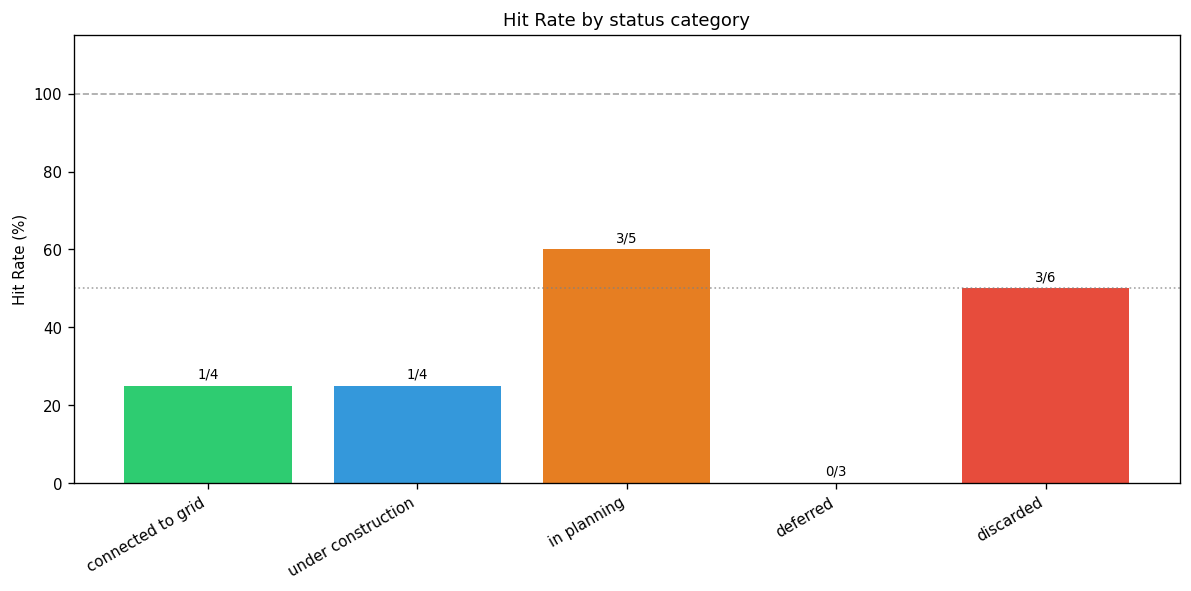

In [84]:
print("=== Hit Rate ===\n")

positive_statuses = ["connected to grid", "under construction", "in planning"]
positive = gdf_plants[gdf_plants["status"].isin(positive_statuses)].copy() # Positive sites
positive["hit"] = positive["suit_value"] > 0                               # Hit = suit > 0
hit_count = int(positive["hit"].sum())                                     # Count hits
hit_rate = hit_count / len(positive) * 100                                 # Percentage
print(f"  Hit Rate positiv: {hit_count}/{len(positive)} ({hit_rate:.1f}%)")

# Hit rate per status group
status_stats = []                                                          # Collect stats
for status in STATUS_ORDER:                                                # All 5 groups
    group = gdf_plants[gdf_plants["status"] == status]                    # Filter
    hits = int((group["suit_value"] > 0).sum())                           # Count hits
    status_stats.append({"Status": status, "Total": len(group),
                         "Treffer": hits,
                         "HitRate": hits/len(group)*100 if len(group) else 0})
df_hit = pd.DataFrame(status_stats)                                        # Summary table
print("\n" + df_hit.to_string(index=False))

# Missing positive sites
for _, r in positive[~positive["hit"]].iterrows():                        # Loop misses
    reason = "OOB" if r.in_constraint == "OOB" else (                     # Determine reason
        "outside constraint" if r.in_constraint != "✓" else "suit ≤ 0")
    print(f"  ⚠ {r['name']}: {reason}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))                                   # Figure
bars = ax.bar(df_hit["Status"], df_hit["HitRate"],                        # Bar plot
              color=[STATUS_COLORS[s] for s in df_hit["Status"]])
for bar, cnt, tot in zip(bars, df_hit["Treffer"], df_hit["Total"]):       # Labels on bars
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+2,
            f"{cnt}/{tot}", ha="center", fontsize=8)
ax.set_ylim(0, 115)                                                       # Y range
ax.axhline(100, color="gray", ls="--", lw=1, alpha=0.7)                  # 100% reference
ax.axhline(50, color="gray", ls=":", lw=1, alpha=0.7)                    # 50% reference
ax.set_ylabel("Hit Rate (%)")                                             # Y label
ax.set_title("Hit Rate by status category")                               # Title
ax.set_xticklabels(df_hit["Status"], rotation=30, ha="right")             # Rotated labels
plt.tight_layout()
fig.savefig(OUT_F / "validation_hitrate.png", dpi=150, bbox_inches="tight")
print(f"\n  ✓ {OUT_F / 'validation_hitrate.png'}")

## 6. Mann-Whitney U Test

Vergleich der realen Standort-Werte gegen zufällige Punkte aus der Constraint-Maske.
Alternative Hypothese: Standort-Werte sind höher als zufällige Werte.

=== Mann-Whitney U ===

  All sites vs. random:    U=4518.0, p=1, r=-0.148
  Positive vs. random:     U=2610.0, p=0.9999, r=-0.117

  ✓ ..\outputs\figures\validation_mannwhitney.png


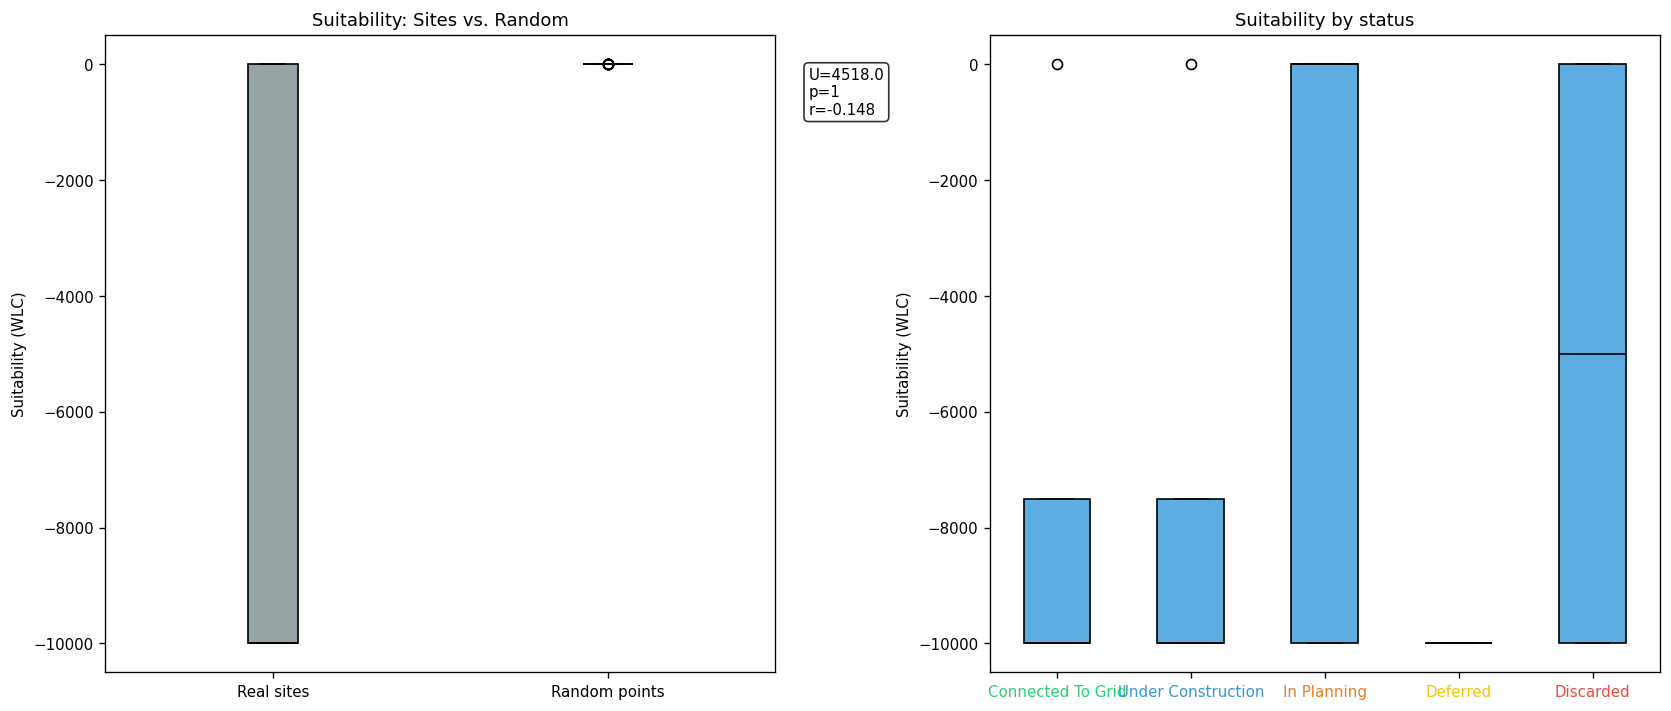

In [85]:
print("=== Mann-Whitney U ===\n")

np.random.seed(42)                                                         # Reproducibility
site_values = gdf_plants["suit_value"].fillna(0).values                    # All 22 sites
valid_values = suit[valid].ravel()                                         # All valid pixels
sample_size = min(1000, len(valid_values))                                 # Sample size
random_values = np.random.choice(valid_values, size=sample_size,           # Random sample
                                 replace=False)

# All sites vs. random
u_stat, p_value = mannwhitneyu(site_values, random_values,                # U-test
                                alternative="greater")
n1, n2 = len(site_values), len(random_values)                              # Sample sizes
z_score = (u_stat - n1*n2/2) / np.sqrt(n1*n2*(n1+n2+1)/12)               # Z-score
effect_size = z_score / np.sqrt(n1 + n2)                                   # Effect size r
print(f"  All sites vs. random:    U={u_stat:.1f}, p={p_value:.4g}, r={effect_size:.3f}")

# Positive sites only vs. random
pos_vals = gdf_plants[gdf_plants["status"].isin(                          # Positive only
    ["connected to grid", "under construction", "in planning"]
)]["suit_value"].fillna(0).values
u_pos, p_pos = mannwhitneyu(pos_vals, random_values, alternative="greater")
z_pos = (u_pos - len(pos_vals)*n2/2) / np.sqrt(                          # Z for positive
    len(pos_vals)*n2*(len(pos_vals)+n2+1)/12)
r_pos = z_pos / np.sqrt(len(pos_vals) + n2)                               # Effect size
print(f"  Positive vs. random:     U={u_pos:.1f}, p={p_pos:.4g}, r={r_pos:.3f}")

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))                           # Two panels

axes[0].boxplot([site_values, random_values],                              # Left: sites vs random
    labels=["Real sites", "Random points"], patch_artist=True,
    boxprops=dict(facecolor="#95a5a6"), medianprops=dict(color="black"))
axes[0].set_title("Suitability: Sites vs. Random")                        # Title
axes[0].set_ylabel("Suitability (WLC)")                                   # Y label
axes[0].text(1.05, 0.95, f"U={u_stat:.1f}\np={p_value:.4g}\nr={effect_size:.3f}",
    transform=axes[0].transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", fc="white", alpha=0.8))

status_data = [gdf_plants[gdf_plants["status"]==s]["suit_value"].dropna() # Right: by status
               for s in STATUS_ORDER]
axes[1].boxplot(status_data, labels=[s.title() for s in STATUS_ORDER],    # Boxplot
    patch_artist=True, boxprops=dict(facecolor="#5dade2"),
    medianprops=dict(color="black"))
axes[1].set_title("Suitability by status")                                # Title
axes[1].set_ylabel("Suitability (WLC)")                                   # Y label
for tick, color in zip(axes[1].get_xticklabels(),                         # Color labels
    [STATUS_COLORS[s] for s in STATUS_ORDER]):
    tick.set_color(color)

plt.tight_layout()
fig.savefig(OUT_F / "validation_mannwhitney.png", dpi=150, bbox_inches="tight")
print(f"\n  ✓ {OUT_F / 'validation_mannwhitney.png'}")

## 7. Kruskal-Wallis über Status-Gruppen

Testet, ob die Eignungswerte sich systematisch zwischen den Status-Kategorien unterscheiden.

In [86]:
print("=== Kruskal-Wallis ===\n")

group_values = [gdf_plants[gdf_plants["status"]==s]["suit_value"].dropna() # Values per group
                for s in STATUS_ORDER]
h_stat, p_kw = kruskal(*group_values)                                     # H-test
print(f"  H = {h_stat:.3f}, p = {p_kw:.4g}, df = {len(group_values)-1}")
print(f"  {'✓ Significant' if p_kw < 0.05 else '⚠ Not significant'} (α = 0.05)")

# Post-hoc pairwise (Bonferroni) if significant
n_comp = sum(1 for i in range(len(STATUS_ORDER))                          # Number of comparisons
             for j in range(i+1, len(STATUS_ORDER)))
if p_kw < 0.05:                                                           # Only if significant
    pairwise = []
    for i in range(len(STATUS_ORDER)):                                    # All pairs
        for j in range(i+1, len(STATUS_ORDER)):
            a, b = group_values[i], group_values[j]
            if len(a) >= 1 and len(b) >= 1:                              # Need data
                u_p, p_p = mannwhitneyu(a, b, alternative="two-sided")    # Pairwise test
                pairwise.append({"A": STATUS_ORDER[i], "B": STATUS_ORDER[j],
                                 "U": round(u_p, 1), "p_adj": min(p_p*n_comp, 1.0)})
    print("\n  Post-hoc (Bonferroni):")
    print(pd.DataFrame(pairwise).to_string(index=False))

# Spearman correlation: weight vs. suitability
valid_sites = gdf_plants.dropna(subset=["suit_value"])                    # Sites with values
rho, p_spear = spearmanr(valid_sites["weight"], valid_sites["suit_value"])
print(f"\n  Spearman ρ = {rho:.3f}, p = {p_spear:.4g}")
print(f"  {'✓ Significant' if p_spear < 0.05 else '⚠ Not significant'}")

=== Kruskal-Wallis ===

  H = 3.626, p = 0.459, df = 4
  ⚠ Not significant (α = 0.05)

  Spearman ρ = -0.173, p = 0.4407
  ⚠ Not significant


## 8. OAT-Sensitivitätsanalyse

One-At-a-Time: Jedes der 10 Gewichte wird einzeln um ±20% variiert,
alle anderen werden proportional angepasst (Σ = 1.0 beibehalten).
20 WLC-Durchläufe.

In [87]:
print("=== OAT Sensitivity ===\n")

# Original weights
W_BASE = {                                                                 # Baseline weights
    "f01_globalstrahlung": 0.25, "f02_wintereinstrahlung": 0.10,
    "f03_hangneigung": 0.12, "f04_exposition": 0.12,
    "f05_hoehenlage": 0.10, "f06_schneebedeckung": 0.06,
    "f07_netzanschluss": 0.08, "f08_strasse": 0.07,
    "f09_infrastruktur": 0.05, "f10_sichtbarkeit": 0.05,
}
DELTA = 0.20                                                               # ±20% variation

# Load criteria rasters
criteria = {}                                                              # Storage
for name in W_BASE:                                                        # Loop criteria
    path = PROC / f"criteria/{name}.tif"                                  # File path
    if path.exists():                                                     # If exists
        with rasterio.open(path) as src:                                  # Open
            criteria[name] = src.read(1)                                  # Read band 1
    else:
        print(f"  ⚠ {name} not found")
print(f"  Loaded: {len(criteria)}/{len(W_BASE)} criteria")

=== OAT Sensitivity ===

  Loaded: 10/10 criteria


In [88]:
def compute_wlc(weights, criteria_dict, mask_2d):
    """Compute WLC from weights and criteria rasters."""
    result = np.zeros((height, width), dtype=np.float32)                   # Init result
    for name, w in weights.items():                                        # Loop criteria
        if name in criteria_dict:                                         # If available
            data = criteria_dict[name]                                    # Get raster
            result += w * np.where((data != NODATA) & mask_2d, data, 0)  # Weighted sum
    return result

# Baseline
suit_base = compute_wlc(W_BASE, criteria, valid)                          # Baseline WLC
base_mean = suit_base[valid & (suit_base > 0)].mean()                     # Baseline mean
print(f"  Baseline mean suitability: {base_mean:.4f}")

# OAT: each weight ±20%
oat_results = []                                                           # Collect results
for target in W_BASE:                                                      # Each criterion
    for direction in [+1, -1]:                                            # +20% and -20%
        w_new = dict(W_BASE)                                              # Copy weights
        adjusted = w_new[target] * (1 + direction * DELTA)                # Adjust target
        w_new[target] = adjusted                                          # Set new weight

        rest_sum = sum(w for k, w in w_new.items() if k != target)        # Sum of others
        scale = (1.0 - adjusted) / rest_sum if rest_sum > 0 else 1       # Re-normalization
        for k in w_new:                                                   # Scale others
            if k != target:
                w_new[k] *= scale                                         # Proportional adjust

        suit_oat = compute_wlc(w_new, criteria, valid)                    # Compute WLC
        oat_mean = suit_oat[valid & (suit_oat > 0)].mean()               # Mean suitability
        change = (oat_mean - base_mean) / base_mean * 100                 # Change in %

        oat_results.append({                                               # Store result
            "criterion": target, "direction": f"{'+'if direction>0 else ''}{int(DELTA*100*direction)}%",
            "new_weight": round(adjusted, 3), "mean_suit": round(oat_mean, 4),
            "change_pct": round(change, 2), "abs_change": round(abs(change), 2),
        })

df_oat = pd.DataFrame(oat_results)                                        # Results table
df_oat.to_csv(OUT_T / "oat_sensitivity.csv", index=False)                 # Save CSV
print(f"\n  {len(df_oat)} runs completed")
print(df_oat.sort_values("abs_change", ascending=False).head(6).to_string(index=False))

  Baseline mean suitability: 0.7776

  20 runs completed
          criterion direction  new_weight  mean_suit  change_pct  abs_change
   f10_sichtbarkeit      +20%       0.060     0.7714       -0.80        0.80
   f10_sichtbarkeit      -20%       0.040     0.7839        0.80        0.80
f01_globalstrahlung      +20%       0.300     0.7823        0.60        0.60
f01_globalstrahlung      -20%       0.200     0.7730       -0.60        0.60
    f03_hangneigung      +20%       0.144     0.7804        0.35        0.35
    f03_hangneigung      -20%       0.096     0.7749       -0.35        0.35


  ✓ ..\outputs\figures\oat_tornado.png


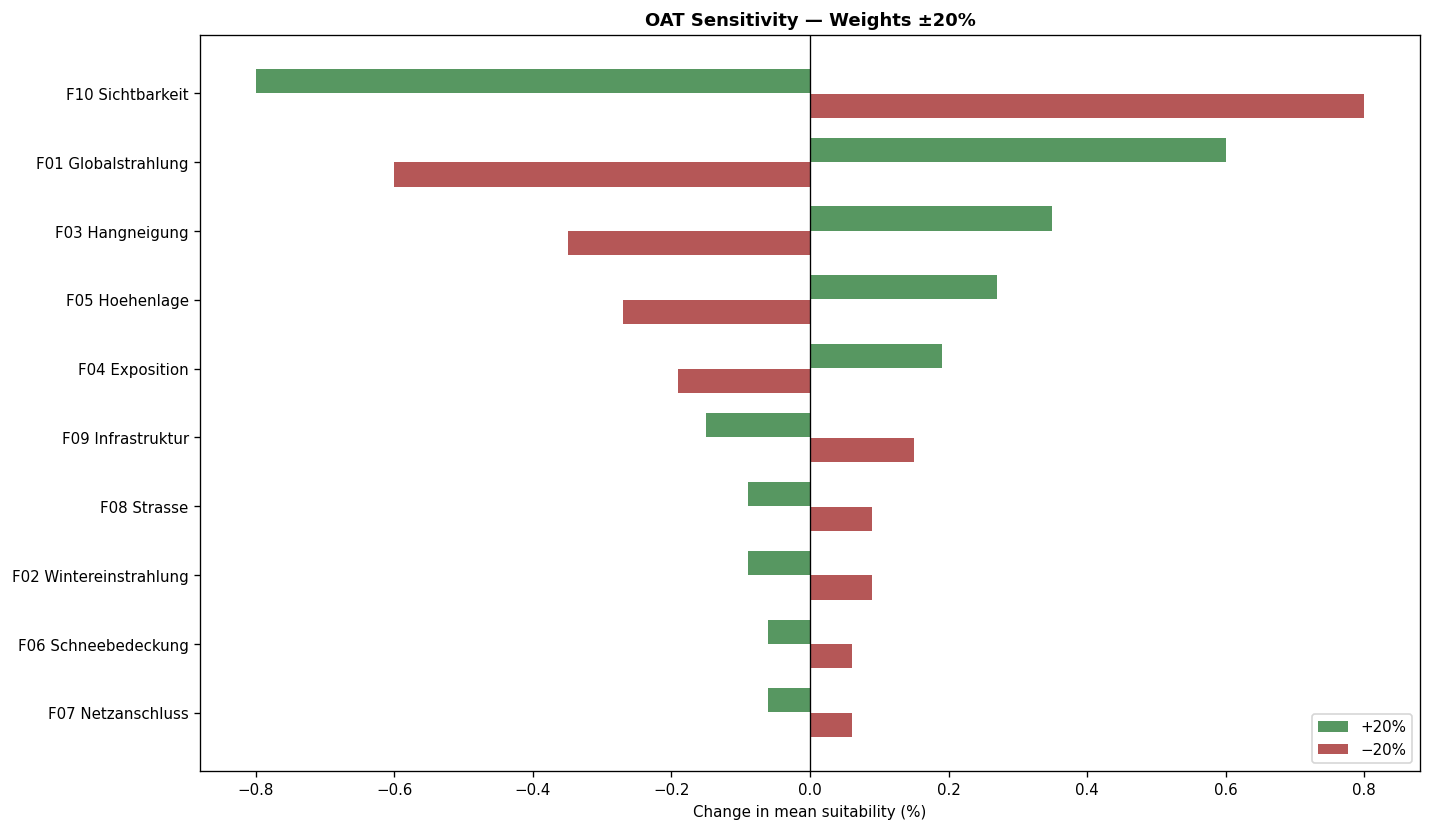

In [89]:
# Tornado diagram
plot_df = df_oat.copy()                                                    # Copy for plotting
plot_df["criterion"] = plot_df["criterion"].str.replace("_"," ").str.title()
order = (plot_df.groupby("criterion")["abs_change"]                       # Sort by impact
         .max().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 7))                                   # Figure
for i, crit in enumerate(order):                                           # Each criterion
    row_p = plot_df[(plot_df.criterion==crit) & plot_df.direction.str.startswith("+")].iloc[0]
    row_m = plot_df[(plot_df.criterion==crit) & plot_df.direction.str.startswith("-")].iloc[0]
    ax.barh(i+0.18, row_p.change_pct, height=0.35,                       # +20% bar (green)
            color="#2D7D3A", alpha=0.8, label="+20%" if i==0 else "")
    ax.barh(i-0.18, row_m.change_pct, height=0.35,                       # -20% bar (red)
            color="#A32D2D", alpha=0.8, label="−20%" if i==0 else "")

ax.set_yticks(range(len(order)))                                          # Y ticks
ax.set_yticklabels(order, fontsize=9)                                     # Y labels
ax.set_xlabel("Change in mean suitability (%)")                           # X label
ax.set_title("OAT Sensitivity — Weights ±20%", fontweight="bold")        # Title
ax.axvline(0, color="black", lw=0.8)                                     # Zero line
ax.legend(loc="lower right")                                              # Legend
plt.tight_layout()
fig.savefig(OUT_F / "oat_tornado.png", dpi=150, bbox_inches="tight")     # Save
print(f"  ✓ {OUT_F / 'oat_tornado.png'}")

## 9. Summary

In [90]:
print(f"{'='*60}")
print(f"  VALIDATION & SENSITIVITY — SUMMARY")
print(f"{'='*60}")

summary_records = [                                                        # Collect all results
    {"Test": "Hit Rate (positive)", "Value": f"{hit_count}/{len(positive)}",
     "Interp.": "✓ Majority inside" if hit_rate >= 50 else "⚠ Low hit rate"},
    {"Test": "Mann-Whitney U", "Value": f"U={u_stat:.1f}, p={p_value:.4g}",
     "Interp.": "✓ Significantly higher" if p_value < 0.05 else "⚠ Not significant"},
    {"Test": "Kruskal-Wallis", "Value": f"H={h_stat:.3f}, p={p_kw:.4g}",
     "Interp.": "✓ Groups differ" if p_kw < 0.05 else "⚠ No difference"},
    {"Test": "Spearman ρ", "Value": f"ρ={rho:.3f}, p={p_spear:.4g}",
     "Interp.": "✓ Significant correlation" if p_spear < 0.05 else "⚠ Not significant"},
    {"Test": "OAT most sensitive", "Value": df_oat.sort_values("abs_change", ascending=False).iloc[0].criterion,
     "Interp.": f"±{df_oat.sort_values('abs_change', ascending=False).iloc[0].abs_change:.2f}% change"},
]

df_summary = pd.DataFrame(summary_records)                                 # Summary table
print(df_summary.to_string(index=False))
df_summary.to_csv(OUT_T / "validation_summary.csv", index=False)          # Save CSV

print(f"\n{'='*60}")
print(f"  Outputs:")
for f in ["validation_plants_map.png", "validation_zoom_madrisasolar.png",
          "validation_hitrate.png", "validation_mannwhitney.png", "oat_tornado.png"]:
    print(f"    {OUT_F / f}")
for f in ["validation_summary.csv", "validation_point_detail.csv", "oat_sensitivity.csv"]:
    print(f"    {OUT_T / f}")
print(f"{'='*60}")

  VALIDATION & SENSITIVITY — SUMMARY
               Test              Value           Interp.
Hit Rate (positive)               5/13    ⚠ Low hit rate
     Mann-Whitney U      U=4518.0, p=1 ⚠ Not significant
     Kruskal-Wallis   H=3.626, p=0.459   ⚠ No difference
         Spearman ρ ρ=-0.173, p=0.4407 ⚠ Not significant
 OAT most sensitive   f10_sichtbarkeit     ±0.80% change

  Outputs:
    ..\outputs\figures\validation_plants_map.png
    ..\outputs\figures\validation_zoom_madrisasolar.png
    ..\outputs\figures\validation_hitrate.png
    ..\outputs\figures\validation_mannwhitney.png
    ..\outputs\figures\oat_tornado.png
    ..\outputs\tables\validation_summary.csv
    ..\outputs\tables\validation_point_detail.csv
    ..\outputs\tables\oat_sensitivity.csv


## Interpretation der Validierungsergebnisse

Die Validierung zeigt ein **gemischtes Bild**: Die Hit Rate der positiven Standorte (realisiert, im Bau, in Planung) liegt bei **5 von 13 (38 %)**, was zunächst gering erscheint. Der Mann-Whitney U-Test (p = 1,0) und der Kruskal-Wallis-Test (H = 3,63, p = 0,46) liefern **keine statistisch signifikanten Unterschiede** zwischen Standort- und Zufallswerten bzw. zwischen den Status-Gruppen. Auch die Spearman-Korrelation zwischen Status-Gewicht und WLC-Score ist schwach (ρ = −0,17, p = 0,44).

Diese Ergebnisse sind jedoch **mit Vorsicht zu interpretieren**: Mehrere bestehende Standorte — darunter Madrisasolar und weitere realisierte Anlagen — fallen in Bereiche mit **hohen WLC-Werten** und bestätigen die Modelllogik qualitativ. Die geringe Trefferquote erklärt sich weniger durch ein schlechtes Modell als durch **methodische Einschränkungen**:

- Viele Validierungsstandorte liegen **ausserhalb der Constraint-Maske** (z. B. Lawinenzonen, Schutzgebiete), da historische Entscheide andere Kriterien berücksichtigten.
- Die Stichprobe ist mit **22 Standorten** sehr klein und damit statistisch kaum aussagekräftig.
- Punktbasierte WLC-Werte sind nur eine Annäherung an die tatsächliche Flächeneignung.

Die **OAT-Sensitivitätsanalyse** zeigt, dass das Modell insgesamt **robust** ist: Selbst das sensibelste Kriterium (f10_Sichtbarkeit) verändert den mittleren Eignungswert um lediglich **±0,80 %**. Dies deutet auf eine **stabile Gewichtungsstruktur** hin.


## Ergebnis

**Validierung:**
- Hit Rate zeigt, wie viele realisierte/geplante Standorte im geeigneten Bereich liegen
- Mann-Whitney U prüft, ob Standort-Werte systematisch höher sind als zufällige Pixel
- Kruskal-Wallis testet Unterschiede zwischen den 5 Status-Gruppen
- Validierungskarte zeigt WLC + Referenz-Polygone + Standorte farbcodiert nach Status

**Sensitivität:**
- OAT identifiziert die Kriterien mit dem grössten Einfluss auf die mittlere Eignung
- Tornado-Diagramm zeigt welche Gewichte stabil bzw. sensibel sind

**Einschränkungen:**
- Nur 22 Standorte — keine repräsentative Stichprobe
- Punkt-basierte Standortwerte als Annäherung an polygonale Referenzen
- Ergebnisse gelten für die aktuellen Constraint- und Gewichtungsannahmen